Epoch 0 | Train Loss: 143.421068 | Val Loss: 74.085281
Epoch 100 | Train Loss: 0.851921 | Val Loss: 0.098244
Epoch 200 | Train Loss: 0.011444 | Val Loss: 0.002413
Epoch 300 | Train Loss: 0.002865 | Val Loss: 0.001545
Epoch 400 | Train Loss: 0.001494 | Val Loss: 0.005468
Epoch 500 | Train Loss: 0.006066 | Val Loss: 0.005480
Epoch 600 | Train Loss: 0.001271 | Val Loss: 0.000561
Epoch 700 | Train Loss: 0.000958 | Val Loss: 0.003623
Epoch 800 | Train Loss: 0.000485 | Val Loss: 0.000319
Epoch 900 | Train Loss: 0.003109 | Val Loss: 0.006372

Best model at epoch 946 with val loss 0.000061


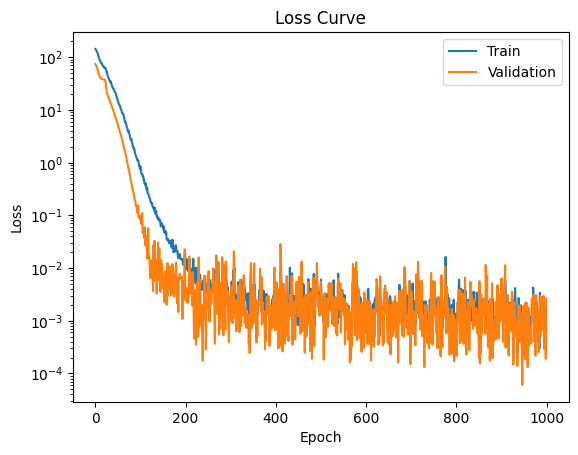

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

x=torch.linspace(-5,5,250).view(-1,1)
y=(x**2).view(-1,1)

indices=torch.randperm(x.shape[0])
x=x[indices]
y=y[indices]

split=int(0.8*len(x))
x_train,x_val=x[:split],x[split:]
y_train,y_val=y[:split],y[split:]

dataset=TensorDataset(x_train,y_train)
dataloader=DataLoader(dataset,batch_size=16,shuffle=True)

class Net(nn.Module):
  def __init__(self):
    super(Net,self).__init__()
    self.input=nn.Linear(1,16)
    self.l1=nn.Linear(16,16)
    self.l2=nn.Linear(16,16)
    self.output=nn.Linear(16,1)

  def forward(self,x):
    x=torch.tanh(self.input(x))
    x=torch.tanh(self.l1(x))
    x=torch.tanh(self.l2(x))
    return self.output(x)

model=Net()
optimizer=optim.Adam(model.parameters(),lr=0.001)
criterion=nn.MSELoss()

train_losses=[]
val_losses=[]

best_val_loss=float('inf')
best_epoch=0

for epoch in range(1000):
  model.train()
  epoch_loss=0

  for batch_x,batch_y in dataloader:
    optimizer.zero_grad()
    pred=model(batch_x)
    loss=criterion(pred,batch_y)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0)
    optimizer.step()
    epoch_loss+=loss.item()

  avg_train_loss=epoch_loss/len(dataloader)
  train_losses.append(avg_train_loss)

  model.eval()
  with torch.no_grad():
    val_pred=model(x_val)
    val_loss=criterion(y_val,val_pred).item()
  val_losses.append(val_loss)

  if val_loss<best_val_loss:
    best_val_loss=val_loss
    best_epoch=epoch
    torch.save(model.state_dict(),'best_model.pt')

  if epoch % 100 == 0:
    print(f'Epoch {epoch} | Train Loss: {avg_train_loss:.6f} | Val Loss: {val_loss:.6f}')

model.load_state_dict(torch.load('best_model.pt'))
print(f'\nBest model at epoch {best_epoch} with val loss {best_val_loss:.6f}')

plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')
plt.show()


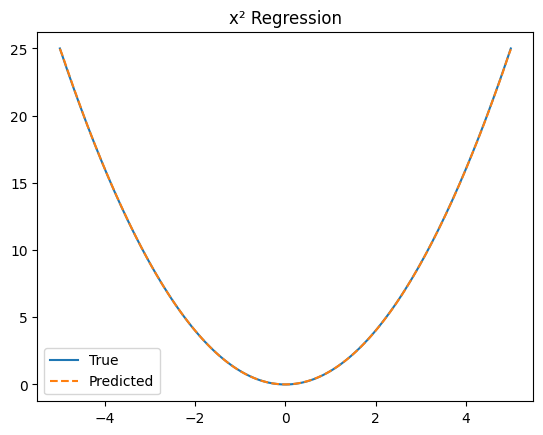

In [8]:
model.eval()
with torch.no_grad():
    x_plot = torch.linspace(-5, 5, 200).view(-1, 1)
    y_pred = model(x_plot)

plt.plot(x_plot.numpy(), x_plot.numpy()**2, label='True')
plt.plot(x_plot.numpy(), y_pred.numpy(), label='Predicted', linestyle='--')
plt.legend()
plt.title('x² Regression')
plt.show()
